<a href="https://colab.research.google.com/github/Jaydenkaleb/Introduction-to-AI/blob/main/Introduction_to_AI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Medical Disease Prediction Using Machine Learning**


The medical dataset (from kaggle) contains synthetic clinical observations of 80 patients, each represented by attributes such as age, weight, blood pressure, glucose and insulin levels, lifestyle habits, and key neurological or physical symptoms. The goal of the dataset is to map patient profiles to potential chronic or neurological diseases, such as Alzheimer's, Parkinson's, Diabetes, Lupus, Stroke, Migraine, General Anxiety, Meningitis, and Cardiovascular Disease.

In [1]:
#Import the necessary linbraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score, GridSearchCV

In [2]:
#load the dataset
df = pd.read_csv("medical_dataset1.csv - Sheet1 (1).csv")

In [3]:
#display the first five records
df.head()

,age,weight,blood_pressure,glucose_level,insulin_level,smoking_habit,symptom_1,symptom_2,symptom_3,disease
0,68,72,140/90,190,30,yes,memory_loss,confusion,disorientation,Alzheimer’s
1,54,80,135/85,105,20,no,tremors,stiff_muscles,speech_issue,Parkinson’s
2,36,65,125/80,180,22,yes,blurred_vision,fatigue,frequent_urination,Diabetes
3,29,60,118/76,95,10,no,joint_pain,rash,fever,Lupus
4,41,70,130/82,100,18,yes,headache,dizziness,nausea,Migraine


In [4]:
#check teh size of the dataset
df.shape

(82, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             82 non-null     int64 
 1   weight          82 non-null     int64 
 2   blood_pressure  82 non-null     object
 3   glucose_level   82 non-null     int64 
 4   insulin_level   82 non-null     int64 
 5   smoking_habit   82 non-null     object
 6   symptom_1       82 non-null     object
 7   symptom_2       82 non-null     object
 8   symptom_3       82 non-null     object
 9   disease         82 non-null     object
dtypes: int64(4), object(6)
memory usage: 6.5+ KB


In [6]:
#statistical summary
df.describe()

,age,weight,glucose_level,insulin_level
count,82.000000,82.000000,82.000000,82.000000
mean,48.695122,74.390244,136.536585,27.402439
std,13.460219,7.468049,35.552151,10.708091
min,25.000000,55.000000,90.000000,10.000000
25%,37.250000,69.000000,105.000000,19.000000
50%,48.000000,75.500000,122.500000,24.000000
75%,60.000000,80.000000,170.000000,37.750000
max,72.000000,87.000000,200.000000,50.000000


In [7]:
#check for missing values
missing_values = df.isnull().sum()

print(missing_values)

age               0
weight            0
blood_pressure    0
glucose_level     0
insulin_level     0
smoking_habit     0
symptom_1         0
symptom_2         0
symptom_3         0
disease           0
dtype: int64


In [9]:
#check for duplicates
Number_of_duplicate_rows=df.duplicated().sum()
print(Number_of_duplicate_rows)

0


In [10]:
print(df["disease"].unique())

['Alzheimer’s' 'Parkinson’s' 'Diabetes' 'Lupus' 'Migraine' 'Stroke'
 'General Anxiety' 'Cardiovascular Disease' 'Meningitis' "Parkinson's"]


**Visualize relationships in the data using charts and graphs to better understand the patterns**

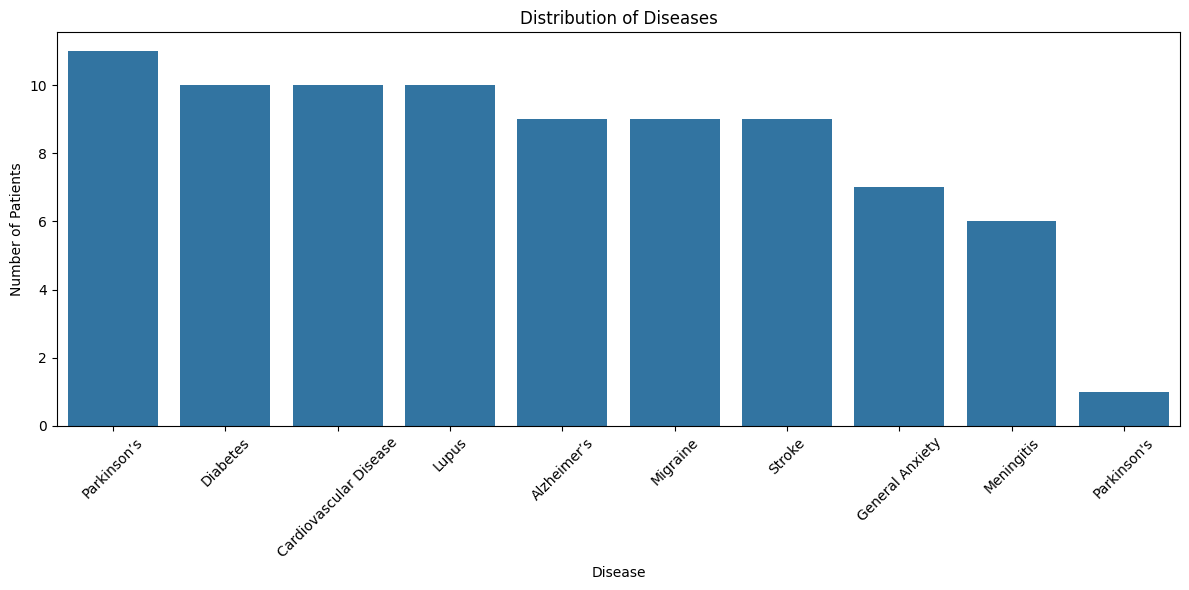

In [11]:
#disease distribution

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="disease",
    order=df["disease"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Diseases")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

This graph shows how many patients belong to each disease category with the lowest number of patient belonging to the Parkinson's disease

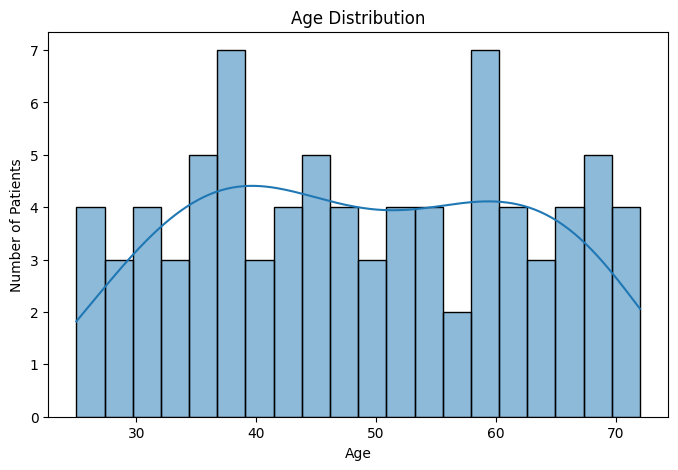

In [12]:
#Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

This graph shows the distribution of patient ages and the number of patient belonging to each age

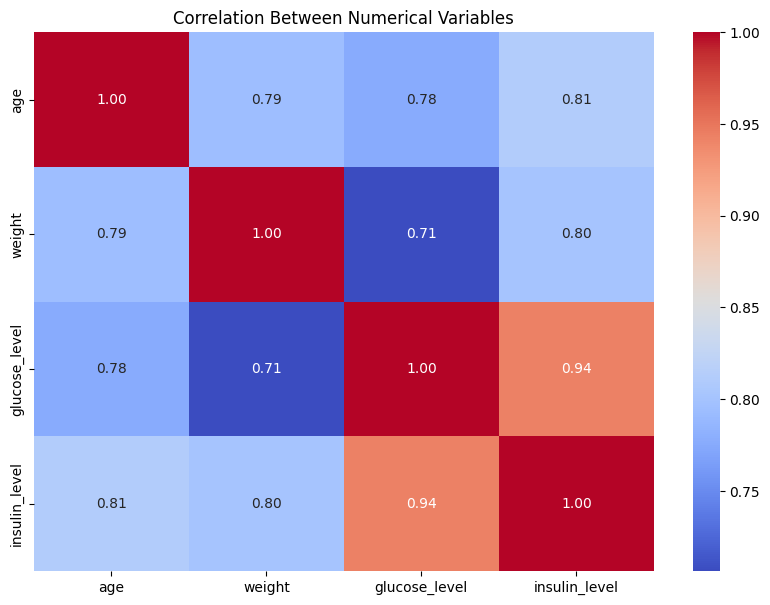

In [18]:
#review the relationship between the numerical variables using the correlation analysis
numeric_columns = [
    "age",
    "weight",
    "glucose_level",
    "insulin_level"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

VaLUES OF 1.00 SHOWS THAT THEY ARE STONGLY RELATED TO EACH OTHER

**Prepare the Data for Machine Learning**

In [19]:
#Identify numerical and categorical varaibles
numeric_features = [
    "age",
    "weight",
    "glucose_level",
    "insulin_level"
]

categorical_features = [
    "smoking_habit",
    "symptom_1",
    "symptom_2",
    "symptom_3"
]

In [23]:
#show the variors taget (disease) to ensure no disease occured only once.
print(df["disease"].value_counts())

disease
Parkinson’s               11
Diabetes                  10
Cardiovascular Disease    10
Lupus                     10
Alzheimer’s                9
Migraine                   9
Stroke                     9
General Anxiety            7
Meningitis                 6
Parkinson's                1
Name: count, dtype: int64


In [26]:
#merging the spelling of parkinson's desease to be one
df["disease"] = df["disease"].replace(
    ["Parkinson’s", "Parkinson's"],
    "Parkinson"
)

#replace Alzheimer's with Alzheimer
df["disease"] = df["disease"].replace(
    ["Alzheimer’s"],
    "Alzheimer"
)

In [27]:
#reprint the disease column
print(df["disease"].value_counts())

disease
Parkinson                 12
Lupus                     10
Diabetes                  10
Cardiovascular Disease    10
Alzheimer                  9
Migraine                   9
Stroke                     9
General Anxiety            7
Meningitis                 6
Name: count, dtype: int64


In [29]:
#define x and y( this will separate teh predictors from the target varaible
X = df.drop(columns=["disease"])
y = df["disease"]

In [30]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
#data preprocessing and visualization- The preprocessing helps teh mahine to learn from teh data as they are
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Encoding and Feature Engineering**

In [35]:
#Convert non-numeric data

df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    dtype=int
)

df_encoded.head()

,age,weight,blood_pressure,glucose_level,insulin_level,disease,smoking_habit_no,smoking_habit_yes,symptom_1_anxiety,symptom_1_blurred_vision,...,symptom_3_stiff_neck,symptom_3_sweating,symptom_3_swelling,symptom_3_thirst,symptom_3_trouble_speaking,symptom_3_trouble_walking,symptom_3_urination,symptom_3_vomiting,symptom_3_weight_loss,symptom_3_word_loss
0,68,72,140/90,190,30,Alzheimer,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,54,80,135/85,105,20,Parkinson,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,36,65,125/80,180,22,Diabetes,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,29,60,118/76,95,10,Lupus,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,41,70,130/82,100,18,Migraine,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


**Model Selection and Development**

I will be using Decision Tree and Random Forest to compare the outcome of the models and see which one is best

In [36]:
#Decision Tree- this makes decision from the outcome of just one tree
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'weight',
                                                   'glucose_level',
                                                   'insulin_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['smoking_habit', 'symptom_1',
                                                   'symptom_2',
                                                   'symptom_3'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [38]:
#Evaluate the model
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    print("Accuracy:",
          accuracy_score(y_test, predictions))

    print("Precision:",
          precision_score(
              y_test,
              predictions,
              average="weighted",
              zero_division=0
          ))

    print("Recall:",
          recall_score(
              y_test,
              predictions,
              average="weighted",
              zero_division=0
          ))

    print("F1 Score:",
          f1_score(
              y_test,
              predictions,
              average="weighted",
              zero_division=0
          ))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

In [39]:
#Evaluate the Decision tree model
evaluate_model(
    tree_model,
    X_test,
    y_test
)

Accuracy: 0.5294117647058824
Precision: 0.45098039215686275
Recall: 0.5294117647058824
F1 Score: 0.47058823529411764

Classification Report:
                        precision    recall  f1-score   support

             Alzheimer       1.00      1.00      1.00         2
Cardiovascular Disease       0.00      0.00      0.00         2
              Diabetes       0.00      0.00      0.00         2
       General Anxiety       0.00      0.00      0.00         1
                 Lupus       1.00      1.00      1.00         2
            Meningitis       0.00      0.00      0.00         1
              Migraine       0.00      0.00      0.00         2
             Parkinson       1.00      1.00      1.00         3
                Stroke       0.33      1.00      0.50         2

              accuracy                           0.53        17
             macro avg       0.37      0.44      0.39        17
          weighted avg       0.45      0.53      0.47        17



In [40]:
#Random Forest- makes decision from analysing the outcome of multiple trees
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'weight',
                                                   'glucose_level',
                                                   'insulin_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['smoking_habit', 'symptom_1',
                                                   'symptom_2',
                                                   'symptom_3'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [41]:
#evaluate the Random forest
evaluate_model(
    rf_model,
    X_test,
    y_test
)

Accuracy: 0.8235294117647058
Precision: 0.8529411764705882
Recall: 0.8235294117647058
F1 Score: 0.8039215686274509

Classification Report:
                        precision    recall  f1-score   support

             Alzheimer       1.00      1.00      1.00         2
Cardiovascular Disease       1.00      0.50      0.67         2
              Diabetes       1.00      0.50      0.67         2
       General Anxiety       0.00      0.00      0.00         1
                 Lupus       1.00      1.00      1.00         2
            Meningitis       0.50      1.00      0.67         1
              Migraine       1.00      1.00      1.00         2
             Parkinson       1.00      1.00      1.00         3
                Stroke       0.50      1.00      0.67         2

              accuracy                           0.82        17
             macro avg       0.78      0.78      0.74        17
          weighted avg       0.85      0.82      0.80        17



In [42]:
#Compare the two Models
models = {
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.529412,0.450980,0.529412,0.470588
1,Random Forest,0.823529,0.852941,0.823529,0.803922


Tecision Tree performed poorly than the Random forest model.

For accuracy the decision tree correctly classify 52.94% of the cases while the random forest correctly classify 82.38%.

For precision the decision tree correct confimed 45.10% of the predicted cases while the random forest model corectly confimed 85.29%.

For recall decision tree identified 52.94% of the actual positive cases while randome forest identified 82.35%.

For F1 Score (which combines the result of precision and recall), The decision tree  shows 47.06% meaning, the model had difficulty balancing precision and recall whicl e for landom forest with a score of 50.39%, indicating the model had a good balance between precison and recal.

**using cross-validation** to evaluate the model rebustness.

Note that with the decision tree and an drandom forest, there was just a single trin data. but with cross validation, there are multiple train from thesame dataset. This will help to ensure that the model is able to work with multiple training dataset and make predictions on teh different instances.

In [49]:
#cross validation used on the decision tree model
cv_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=6, #6 meanis there will be 6 training parts. it can be any number
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.27272727 0.45454545 0.45454545 0.54545455 0.54545455 0.5       ]
Mean CV accuracy: 0.4621212121212121


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=6.
  warnings.warn(


With the 6 trained fold, the model achieved an average accuracy of about 76.21% on data that it did not train for teh decision tree.

In [48]:
#cross validation used on teh random forest model
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=6, #6 meanis there will be 6 training parts. it can be any number
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=6.
  warnings.warn(


Cross-validation scores: [0.72727273 0.72727273 0.81818182 0.90909091 0.54545455 0.8       ]
Mean CV accuracy: 0.7545454545454545


With the 6 trained fold, the model achieved an average accuracy of about 75.45% on data that it did not train for teh random forest. This means that the random forest correctly classified about 75.45% of the training data accross 6 cross validation

but when evaluated separetly, it acieved an accuracy of 82.35%

**hyperparameter tuning to improve its performance**

comparing the decison tree and random forest, teh random forest perform better in predicting the data correctly. therefore i will use hyperparameter to optimize teh performance of Random forest.

In [55]:
#using Hyper parameter to optimize teh performance
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid=param_grid
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


**Evaluate the Tuned Model**

In [52]:
#Evaluate the Tunned Model_
best_model = grid_search.best_estimator_

tuned_predictions = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, tuned_predictions))

print(
    "Precision:",
    precision_score(
        y_test,
        tuned_predictions,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        tuned_predictions,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        tuned_predictions,
        average="weighted",
        zero_division=0
    )
)

Accuracy: 0.8235294117647058
Precision: 0.8039215686274509
Recall: 0.8235294117647058
F1 Score: 0.796078431372549


Random Forest Scores had accuracy of 82.35%

Cross Validation had mean accuracy of 75.45%

Tuned Scores had an accuracy of 82.35%


**Interpretation**
The Tune model performed exactly like the random forest model with both having accuracy rate of 82.35%.

In [56]:
#feature Selection  to help understand which variable in the Random Forest are used moste in making the predictions.
preprocessor_fitted = best_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_names

array(['num__age', 'num__weight', 'num__glucose_level',
       'num__insulin_level', 'cat__smoking_habit_no',
       'cat__smoking_habit_yes', 'cat__symptom_1_anxiety',
       'cat__symptom_1_blurred_vision', 'cat__symptom_1_chest_pain',
       'cat__symptom_1_chest_tightness', 'cat__symptom_1_confusion',
       'cat__symptom_1_dizziness', 'cat__symptom_1_excessive_thirst',
       'cat__symptom_1_fatigue', 'cat__symptom_1_fever',
       'cat__symptom_1_frequent_urination', 'cat__symptom_1_headache',
       'cat__symptom_1_headaches', 'cat__symptom_1_joint_pain',
       'cat__symptom_1_memory_loss', 'cat__symptom_1_neck_pain',
       'cat__symptom_1_neck_stiffness', 'cat__symptom_1_numbness',
       'cat__symptom_1_rash', 'cat__symptom_1_restlessness',
       'cat__symptom_1_shortness_breath', 'cat__symptom_1_slurred_speech',
       'cat__symptom_1_speech_difficulty', 'cat__symptom_1_tremors',
       'cat__symptom_1_vision_blur', 'cat__symptom_2_anxiety',
       'cat__symptom_2_apathy',

In [57]:
rf_classifier = best_model.named_steps["classifier"]

importance = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__age,0.107226
2,num__glucose_level,0.089003
1,num__weight,0.076808
28,cat__symptom_1_tremors,0.074839
3,num__insulin_level,0.071315
19,cat__symptom_1_memory_loss,0.045073
8,cat__symptom_1_chest_pain,0.030017
6,cat__symptom_1_anxiety,0.025569
37,cat__symptom_2_dizziness,0.021188
16,cat__symptom_1_headache,0.020451


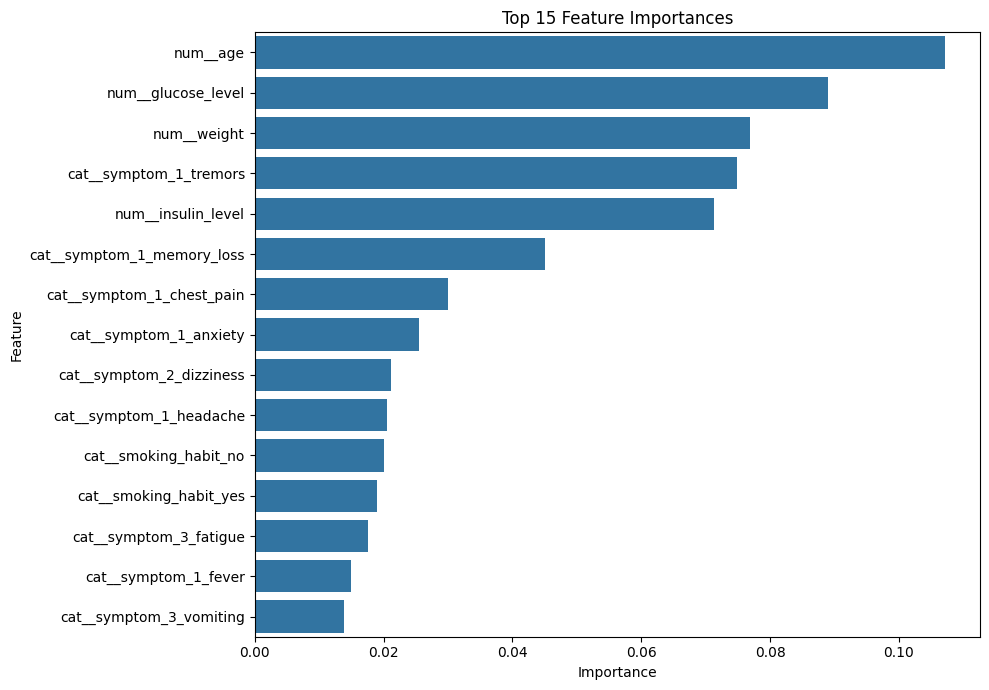

In [58]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Age shows the hightest importance it is to predict the kind of desease you have. among others are insulin leve, weight, tremors, glocose level.


**Regularization**

In [59]:
# regularization help the model not to be overfitted by it learn from more general pattern
logistic_regularized = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=1.0,
            penalty="l2",
            max_iter=2000
        ))
    ]
)

In [60]:
#train the logistic regression
logistic_regularized.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'weight',
                                                   'glucose_level',
                                                   'insulin_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['smoking_habit', 'symptom_1',
                                                   'symptom_2',
                                                   'symptom_3'])])),
                ('classifier', LogisticRegression(max_iter=2000))])

In [61]:
#make the prediction
y_pred_logistic = logistic_regularized.predict(X_test)

In [62]:
#print the result
print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Precision:",
      precision_score(
          y_test,
          y_pred_logistic,
          average="weighted",
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_logistic,
          average="weighted",
          zero_division=0
      ))

print("F1 Score:",
      f1_score(
          y_test,
          y_pred_logistic,
          average="weighted",
          zero_division=0
      ))

Logistic Regression Results
---------------------------
Accuracy: 0.8823529411764706
Precision: 0.9411764705882353
Recall: 0.8823529411764706
F1 Score: 0.8823529411764706


Using the logistic Regression, All the matrices improved.
**accuracy** from 82.35% to 88.23%
**Precision** from 80.39% to 94.11%
**Recall** from 82.35% to 88.23% and
**f1-score from 79.60% to 88.23%